[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/Simone-Alghisi/HMD-Lab/blob/master/elevenlabs_labs/2_emotion_in_dialogue.ipynb)

On Colab:
1. Run the cell below to install the required package
2. Paste the API key we gave you in the *Setup* section
3. For Exercise 4 the recordings must be in `data/dailytalk`: the first cell of Exercise 4 downloads them if the folder is missing

In [1]:
!pip install -q elevenlabs
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.7 MB/s eta 0:00:00


# Emotion in Dialogue Lab

In this lab you will **generate**, **synthesize** and **compare** spoken dialogues with a
**controlled emotional behaviour**:

1. Warm Up: AudioTags and Emotions
2. Situated Emotions (the Modal model)
3. Empathy and Affective Scenes
4. Realistic vs. Synthetic Emotion

The goal is to understand how emotions arise and change, turn after turn, in a dialogue, and to
compare synthetic emotional speech with human emotional speech.

For each exercise:
1. Write your LLM prompt to generate several emotional versions of the same text dialogue (ChatGPT)
2. Synthesize every version with the **same voices**, so that only the emotion changes (ElevenLabs, in this notebook)
3. Listen and analyze the **differences** between the versions
4. In the last exercise, compare your synthesis with a **human** recording

## Setup

Paste the API key we gave you in the cell below.

In [2]:
from elevenlabs import save
from elevenlabs.client import ElevenLabs

ELEVENLABS_API_KEY = "sk_50de9ba17d1e43ce8098732b46199e162be9e8ac5ea1c038"

client = ElevenLabs(api_key=ELEVENLABS_API_KEY)

## Voices

Each speaker needs a `voice_id`. Not all the voices are the same: **try different ones**.

- Keep the **same voices** for all the versions of a dialogue, otherwise you change more than the emotion.
- The voice must match the tag: a calm, serious voice may not sound convincing with an `[excited]` tag.

In [3]:
# Run this to see the voices available with the key
for v in client.voices.search().voices:
    print(v.name, v.voice_id)

VOICE_A = "cgSgspJ2msm6clMCkdW9"   # Speaker A (e.g. Customer)
VOICE_B = "iP95p4xoKVk53GoZ742B"   # Speaker B (e.g. Agent)

Jarnathan - warm, confident, versatile c6SfcYrb2t09NHXiT80T
Jack John - Conversational and Upbeat 7EzWGsX10sAS4c9m9cPf
Veda Sky - Natural, Mindful and Caring XcXEQzuLXRU9RcfWzEJt
Siren - Natural realistic conversational voice eXpIbVcVbLo8ZJQDlDnl
Luke - Calm, Warm and Conversational RNnkVeW25AwKYxZgnHBH
A Serak - Deep, hoarse. LxiqOV1uxBCgYTeitAHf
Mr. Chen - Trustworthy Chinese Narrator cwzmKSYMCC9Aym1ymCnt
Bateman - Deep and Seductive XTdzBt8oIEvodkwhxeA0
Grandpa Spuds Oxley NOpBlnGInO9m6vDvFkFC
Kittie KaBoom - Young dynamic female voice 0luPAj5RsdhmnkZaiYcb


## Synthesis

A dialogue is a list of turns. Each turn is a dictionary with the `voice_id` of the speaker
and the `text` to synthesize:

```python
{"voice_id": VOICE_A, "text": "[worried] Hi, my suitcase did not arrive with my flight from Berlin."}
```

The function below sends the dialogue to ElevenLabs, saves the audio and plays it.

You can also choose the **stability** of the generation
(`0.0` = Creative, `0.5` = Natural, `1.0` = Robust): lower it if an emotion tag
does not seem to have any effect.

In [4]:
from IPython.display import Audio, display


def synthesize(dialogue, filename, stability=0.5):
    audio = client.text_to_dialogue.convert(
        inputs=dialogue,
        model_id="eleven_v4",
        # Lower stability generally gives tags more influence.
        # Remove this parameter if your installed SDK version rejects it.
        settings={
            "stability": stability,
        },
        # output_format="mp3_44100_128",
    )
    save(audio, filename)
    print("Saved:", filename)
    display(Audio(filename))

Quick test to check that the key and the voices work:

In [5]:
test = [
    {"voice_id": VOICE_A, "text": "Hello, this is a test of the first voice."},
    {"voice_id": VOICE_B, "text": "And this is the second voice."},
]

synthesize(test, "test.mp3")

Saved: test.mp3


## Describing Emotions

Every dialogue carries a **linguistic tier** (what is said) and an **affective tier**: the emotions
of the speakers. Psychology offers two families of theories to describe an emotion:

- **Basic Emotions** (Ekman, 1999): a small set of discrete, universal emotions:
  *happiness, sadness, anger, fear, surprise, disgust*. They tell us **which** emotion the speaker
  feels, not **how much**.
- **Dimensions of Emotions** (Russell, 1980): emotions are points in a continuous space with two dimensions:
  - **Valence**: how pleasant the stimulus is (happy vs. unhappy)
  - **Arousal**: the level of alertness or energy it provokes (excited vs. calm)

## Emotion AudioTags

In ElevenLabs, emotions are represented by AudioTags: natural-language instructions in square
brackets that influence how a turn is delivered. You can combine more than one.

- **Emotions**: `[happy]`, `[sad]`, `[angry]`, `[excited]`, `[tired]`, `[sorrowful]`, `[worried]`, `[annoyed]`, `[relieved]`
- **Delivery**: `[calm]`, `[softly]`, `[warmly]`, `[reassuring]`, `[apologetic]`
- **Sound effects**: `[sighs]`, `[laughs]`, `[gulps]`

Since tags are free text, you can add intensity adverbs to condition the **arousal**:
`[slightly happy]`, `[happy]`, `[extremely happy]`.

The delivery does not depend only on the tag:
- **Punctuation**: `!` and `?` change emphasis and intonation
- **Capitals**: CAPITALS add emphasis
- **The voice**: it must match the tag
- **The text**: the tag works best when the words carry the same emotion

Tags are **instructions**, not **evidence** that the emotion was actually delivered: always check
what you hear.

In [6]:
# (Optional) Same sentence and voice, increasing arousal: can you hear the difference?
# Try also adding "!" or CAPITALS to the text.
intensity = [
    {"voice_id": VOICE_A, "text": "[slightly happy] I passed the exam."},
    {"voice_id": VOICE_A, "text": "[happy] I passed the exam."},
    {"voice_id": VOICE_A, "text": "[extremely happy] I passed the exam."},
]

synthesize(intensity, "intensity.mp3")

Saved: intensity.mp3


# Exercise 1 - Warm Up

**Goal:** hear how AudioTags **change** the way the same utterances are spoken.

Generate a two-speaker dialogue between a Customer and an Agent with ChatGPT and synthesize it in
**3 versions**:
1. **One** dialogue without AudioTags
2. **Two** dialogues with **different** AudioTags (e.g. a *worried* Customer and an *angry* Customer)

Use the same voices and the same utterances for all three versions, then listen:
1. Can you hear a difference between the three versions?
2. Does every turn change, or only some of them?

In [7]:
# Dialogue without AudioTags (add as many turns as you need)
plain = [
    {"voice_id": VOICE_A, "text": "Hi, I’m calling because my order was supposed to arrive yesterday, but I still haven’t received it."},
    {"voice_id": VOICE_B, "text": "I’m sorry about that. Let me check the tracking information for you."},
    {"voice_id": VOICE_A, "text": "Thank you. I really need the package as soon as possible."},
    {"voice_id": VOICE_B, "text": "I understand. I can see that the package was delayed at the distribution center and is now expected to arrive tomorrow."},
    {"voice_id": VOICE_A, "text": "Okay, I appreciate you checking."},
    {"voice_id": VOICE_B, "text": "You’re welcome. I’ll also make a note of the delay on your order."},
]

synthesize(plain, "ex1_plain.mp3")

Saved: ex1_plain.mp3


In [8]:
# Version A: same dialogue, first set of AudioTags
version_a = [
    {"voice_id": VOICE_A, "text": "[worried] Hi, I’m calling because my order was supposed to arrive yesterday, but I still haven’t received it."},
    {"voice_id": VOICE_B, "text": "I’m sorry about that. Let me check the tracking information for you."},
    {"voice_id": VOICE_A, "text": "[anxious] Thank you. I really need the package as soon as possible."},
    {"voice_id": VOICE_B, "text": "I understand. I can see that the package was delayed at the distribution center and is now expected to arrive tomorrow."},
    {"voice_id": VOICE_A, "text": "[relieved] Okay, I appreciate you checking."},
    {"voice_id": VOICE_B, "text": "You’re welcome. I’ll also make a note of the delay on your order."},
]

synthesize(version_a, "ex1_version_a.mp3")

Saved: ex1_version_a.mp3


In [9]:
# Version B: same dialogue, different AudioTags
version_b = [
    {"voice_id": VOICE_A, "text": "[angry] Hi, I’m calling because my order was supposed to arrive yesterday, but I still haven’t received it."},
    {"voice_id": VOICE_B, "text": "I’m sorry about that. Let me check the tracking information for you."},
    {"voice_id": VOICE_A, "text": "[frustrated] Thank you. I really need the package as soon as possible."},
    {"voice_id": VOICE_B, "text": "I understand. I can see that the package was delayed at the distribution center and is now expected to arrive tomorrow."},
    {"voice_id": VOICE_A, "text": "[still frustrated] Okay, I appreciate you checking."},
    {"voice_id": VOICE_B, "text": "You’re welcome. I’ll also make a note of the delay on your order."},
]

synthesize(version_b, "ex1_version_b.mp3")

Saved: ex1_version_b.mp3


# Exercise 2 - Situated Emotions

Emotions do not change at random. In the **Modal model** (Gross, 1998) every emotion arises from a
situation, external (an event, someone's words) or internal (a thought, a memory):

**Situation** (an event) → **Attention** (the person must notice it) → **Appraisal** (the person
evaluates what it means for them) → **Response** (shows in behaviour, words and voice, and in the body)

The response changes the situation, and the cycle starts again. In a dialogue, each turn changes
the situation: how it is appraised decides the response, and the response becomes the next situation.

Apply the Modal model and create 3 versions of the same dialogue between a Customer and an Agent:
1. **Coherent**: every change in the Customer's emotion is caused by what the Agent says
2. **Alternative**: change **one** Agent turn, then rewrite the Customer turns that follow it
3. **Random**: same utterances as the coherent version, but a random emotion tag at every Customer turn

Questions:
1. Which Agent turn causes each change in the Customer's emotion?
2. How does changing one Agent turn change the rest of the dialogue?
3. Does the random version sound strange? Why?

In [10]:
# 1. Coherent: every change in the Customer's emotion is caused by an Agent turn
coherent = [
    {"voice_id": VOICE_A, "text": "[worried] Hi, I’m calling because my order was supposed to arrive yesterday, but I still haven’t received it."},
    {"voice_id": VOICE_B, "text": "I’m sorry about that. Let me check the tracking information for you."},
    {"voice_id": VOICE_A, "text": "[anxious] Thank you. I really need the package as soon as possible."},
    {"voice_id": VOICE_B, "text": "I understand. I can see that the package was delayed at the distribution center, but it has now been released and is expected to arrive tomorrow."},
    {"voice_id": VOICE_A, "text": "[relieved] Okay, that’s good to hear. I appreciate you checking."},
    {"voice_id": VOICE_B, "text": "You’re welcome. I’ll also make a note of the delay on your order."},
]

synthesize(coherent, "ex2_coherent.mp3")

Saved: ex2_coherent.mp3


In [11]:
# 2. Alternative: change ONE Agent turn of the coherent version,
#    then rewrite the Customer turns that follow it
alternative = [
    {"voice_id": VOICE_A, "text": "[worried] Hi, I’m calling because my order was supposed to arrive yesterday, but I still haven’t received it."},
    {"voice_id": VOICE_B, "text": "I’m sorry about that. Let me check the tracking information for you."},
    {"voice_id": VOICE_A, "text": "[anxious] Thank you. I really need the package as soon as possible."},
    {"voice_id": VOICE_B, "text": "I understand. I can see that the package is still stuck at the distribution center, and unfortunately I can’t confirm when it will arrive."},
    {"voice_id": VOICE_A, "text": "[frustrated] Oh, that’s really disappointing. I needed to know when I could expect it."},
    {"voice_id": VOICE_B, "text": "I understand your frustration. I’ll keep monitoring the shipment and update the order as soon as there’s new information."},
]
synthesize(alternative, "ex2_alternative.mp3")

Saved: ex2_alternative.mp3


In [12]:
# 3. Random: same utterances as the coherent version,
#    but a random emotion tag at every Customer turn
random_version = [
    {"voice_id": VOICE_A, "text": "[angry] Hi, I’m calling because my order was supposed to arrive yesterday, but I still haven’t received it."},
    {"voice_id": VOICE_B, "text": "I’m sorry about that. Let me check the tracking information for you."},
    {"voice_id": VOICE_A, "text": "[happy] Thank you. I really need the package as soon as possible."},
    {"voice_id": VOICE_B, "text": "I understand. I can see that the package was delayed at the distribution center, but it has now been released and is expected to arrive tomorrow."},
    {"voice_id": VOICE_A, "text": "[angry] Okay, that’s good to hear. I appreciate you checking."},
    {"voice_id": VOICE_B, "text": "You’re welcome. I’ll also make a note of the delay on your order."},
]

synthesize(random_version, "ex2_random.mp3")

Saved: ex2_random.mp3


# Exercise 3 - Empathy and Affective Scenes

**Empathy** is an affective and cognitive ability that enables the recognition of the affective
signals generated by others, and the reaction to them: an emotional state triggered by another's
emotional state or situation, in which one feels what the other feels (or would normally be expected
to feel) in that situation.

The **affective scene** (Danieli, Riccardi and Alam, 2015) describes how the emotions of the two
speakers change, from the first event to the end of the conversation. For example:

Customer *worried* → Agent *calm* → Customer *anxious* → Agent *empathy* → Customer *relieved*

Here the Agent's empathy turns the Customer's worry into relief.

Create two dialogues between a Customer and an Agent:
1. **Non-empathic Agent**
2. **Empathic Agent**

In both dialogues the Customer starts with **the same request** and the Agent ends with
**the same solution**.

Listen and compare:
1. Where do you hear the empathy: in the words, in the tags, or in the order of what is said?
2. How does the affective scene evolve in each dialogue?

In [13]:
non_empathic = [
    {"voice_id": VOICE_A, "text": "[worried] Hi, I'm calling because my critical medical package was supposed to arrive yesterday and it's still not here."},
    {"voice_id": VOICE_B, "text": "[calm] I need your tracking number to look that up."},
    {"voice_id": VOICE_A, "text": "[anxious] It is 987654321. Please, I really need this medicine immediately."},
    {"voice_id": VOICE_B, "text": "[calm] It is at the regional hub. I will mark it for priority delivery tomorrow."},
    {"voice_id": VOICE_A, "text": "[worried] Okay, I hope it actually arrives this time."}
]

synthesize(non_empathic, "ex3_non_empathic.mp3")

Saved: ex3_non_empathic.mp3


In [14]:
empathic = [
    {"voice_id": VOICE_A, "text": "[worried] Hi, I'm calling because my critical medical package was supposed to arrive yesterday and it's still not here."},
    {"voice_id": VOICE_B, "text": "[warmly] Oh, I am so sorry to hear that. Let me look into this immediately for you. What is the tracking number?"},
    {"voice_id": VOICE_A, "text": "[anxious] It is 987654321. Please, I really need this medicine immediately."},
    {"voice_id": VOICE_B, "text": "[apologetic] I completely understand how stressful this must be. I can see it's at the hub, and I'm upgrading this to priority courier delivery first thing tomorrow morning so you get it safely."},
    {"voice_id": VOICE_A, "text": "[relieved] Oh, thank goodness. I really appreciate your help and understanding."}
]

synthesize(empathic, "ex3_empathic.mp3")

Saved: ex3_empathic.mp3


The function below draws the affective scene of a dialogue from the tags at the beginning of each
turn. It shows the **intended** scene: compare it with what you actually hear.
You can also use it on the dialogues of Exercise 2.

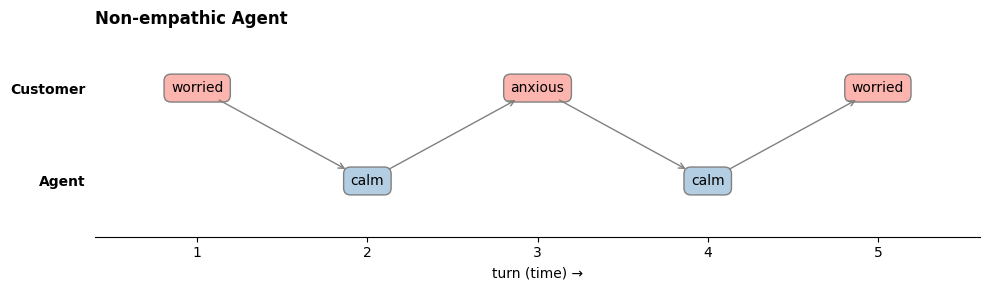

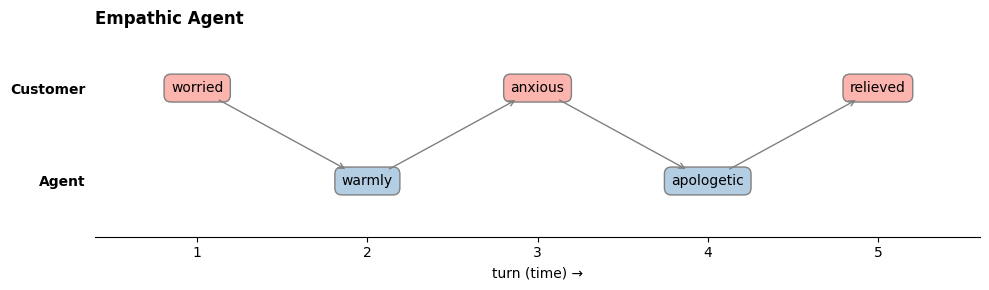

In [15]:
import re
import matplotlib.pyplot as plt


def get_tags(text):
    """Return the AudioTags at the beginning of a turn, e.g. ['relieved', 'sighs']."""
    leading = re.match(r"\s*(?:\[[^\]]*\]\s*)*", text).group(0)
    return re.findall(r"\[([^\]]*)\]", leading)


def plot_affective_scene(dialogue, speakers, title=""):
    """Draw the emotions of the speakers turn after turn.

    speakers: dictionary {voice_id: name}, from the top row to the bottom row.
    """
    rows = list(speakers)
    colors = plt.cm.Pastel1.colors
    fig, ax = plt.subplots(figsize=(1.7 * len(dialogue) + 1.5, 0.9 * len(rows) + 1.2))

    previous = None
    for i, turn in enumerate(dialogue):
        row = rows.index(turn["voice_id"])
        y = len(rows) - 1 - row
        label = "\n".join(get_tags(turn["text"])) or "no tag"
        ax.text(i, y, label, ha="center", va="center", fontsize=10,
                bbox=dict(boxstyle="round,pad=0.5", fc=colors[row % len(colors)], ec="gray"))
        if previous is not None:
            ax.annotate("", xy=(i, y), xytext=previous,
                        arrowprops=dict(arrowstyle="->", color="gray", shrinkA=18, shrinkB=18))
        previous = (i, y)

    ax.set_xlim(-0.6, len(dialogue) - 0.4)
    ax.set_ylim(-0.6, len(rows) - 0.4)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([speakers[v] for v in reversed(rows)], fontweight="bold")
    ax.set_xticks(range(len(dialogue)))
    ax.set_xticklabels(range(1, len(dialogue) + 1))
    ax.set_xlabel("turn (time) →")
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(left=False)
    ax.set_title(title, loc="left", fontweight="bold")
    plt.tight_layout()
    plt.show()


SPEAKERS = {VOICE_A: "Customer", VOICE_B: "Agent"}

plot_affective_scene(non_empathic, SPEAKERS, "Non-empathic Agent")
plot_affective_scene(empathic, SPEAKERS, "Empathic Agent")

# Exercise 4 - Realistic vs. Synthetic Emotion

**DailyTalk** (Lee, Park and Kim, ICASSP 2023) is a dataset of spoken dialogues:
- The dialogues come from **DailyDialog**: conversations about daily life, written for English learners
- They were recorded in a studio by two **voice actors**, a man and a woman, who **acted** the emotion label of every turn
- **Realistic, not real**: natural-sounding speech, but scripted and acted, not spontaneous conversation

You receive three conversations from DailyTalk: the recordings (in `data/dailytalk`) and the texts,
without labels.

1. **Listen** to each recording and **tag** every turn with one of the dataset categories:
   *no emotion, happiness, surprise, sadness, anger, fear, disgust*
2. **Compare** your tags with the labels of the dataset
3. **Synthesize** each dialogue with ElevenLabs, using the dataset labels as AudioTags
   (e.g. `anger` → `[angry]`) and two voices similar to the actors of the recording
4. **Listen** to the recording and to the generated dialogue, and compare them

## Recordings

Each recording is a `.wav` file named after its conversation, with `_` between the words
(e.g. `concert_tickets.wav`).

In [16]:
import subprocess
from pathlib import Path

DATA_DIR = Path("data/dailytalk")

# On Colab the folder is not there: download it from the course repository
REPO_DATA_DIR = Path("HMD-Lab/elevenlabs_labs/data/dailytalk")
if not DATA_DIR.exists():
    if not REPO_DATA_DIR.exists():
        subprocess.run(["git", "clone", "-q", "--depth", "1",
                        "https://github.com/Simone-Alghisi/HMD-Lab.git"])
    DATA_DIR = REPO_DATA_DIR

RECORDINGS = {p.stem.lower(): p for p in sorted(DATA_DIR.glob("*.wav"))}
print("Recordings found:", list(RECORDINGS) or f"none, check the folder {DATA_DIR}")

CATEGORIES = ["no emotion", "happiness", "surprise", "sadness", "anger", "fear", "disgust"]


def play_recording(name):
    path = RECORDINGS.get(name)
    if path is None:
        print(f"Recording '{name}' not found in {DATA_DIR}")
        return
    print("Recording:", path.name)
    display(Audio(str(path)))

Recordings found: ['burnt_bread', 'concert_tickets', 'plane_reservations']


## Step 1 - Listen and Tag

Listen to each recording and write one of the dataset categories in the `"label"` field of every turn:
`no emotion`, `happiness`, `surprise`, `sadness`, `anger`, `fear`, `disgust`.

Tag what you **hear**, not only what you read.

### Concert Tickets

In [17]:
play_recording("concert_tickets")

Recording: concert_tickets.wav


In [20]:
concert_tickets = [
    {"speaker": "S1", "label": "surprise", "text": "What? How could you forget to reserve the concert tickets?"},
    {"speaker": "S0", "label": "no emotion", "text": "I'm sorry. I forget all about it."},
    {"speaker": "S1", "label": "no emotion", "text": "How could you? I reminded you just this morning."},
    {"speaker": "S0", "label": "no emotion", "text": "It's leap my mind. I really feel terrible about it."},
    {"speaker": "S1", "label": "angry", "text": "I have been looking forward to this performance all month."},
    {"speaker": "S0", "label": "sadness", "text": "I'm really sorry I let you down. I'll make it up to you somehow."},
]

### Burnt Bread

In [18]:
play_recording("burnt_bread")

Recording: burnt_bread.wav


In [25]:
burnt_bread = [
    {"speaker": "S0", "label": "surprise", "text": "Something's burning?"},
    {"speaker": "S1", "label": "surprise", "text": "Oh, my bread!"},
    {"speaker": "S0", "label": "happiness", "text": "Umm, I love burnt bread."},
    {"speaker": "S1", "label": "anger", "text": "Curse this oven! Curse it!"},
    {"speaker": "S0", "label": "no emotion", "text": "But I prefer burnt bread."},
    {"speaker": "S1", "label": "anger", "text": "Curse the worst oven in the world."},
    {"speaker": "S0", "label": "happiness", "text": "Wonderful! A perfect piece of bread!"},
    {"speaker": "S1", "label": "disgust", "text": "There are thirteen of them. Oh, have another. Have a third, if you like, have them all."},
]

### Plane Reservations

In [19]:
play_recording("plane_reservations")

Recording: plane_reservations.wav


In [22]:
plane_reservations = [
    {"speaker": "S0", "label": "no emotion", "text": "Brooke, I have bad news."},
    {"speaker": "S1", "label": "fear", "text": "What!"},
    {"speaker": "S0", "label": "anger", "text": "I called the airlines to reconfirm the reservations today."},
    {"speaker": "S1", "label": "anger", "text": "Don't you dare tell me that..."},
    {"speaker": "S0", "label": "sadness", "text": "I'm sorry. I didn't reconfirm in time and they gave away half of the seats."},
    {"speaker": "S1", "label": "anger", "text": "Well, they should have called you!"},
    {"speaker": "S0", "label": "sadness", "text": "They said that they did. I've been so busy..."},
    {"speaker": "S1", "label": "anger", "text": "And you didn't think to leave them my cell phone?"},
    {"speaker": "S0", "label": "surprise", "text": "I didn't think there would be a problem."},
    {"speaker": "S1", "label": "anger", "text": "It's the holidays! Everybody knows how hard it is to get tickets!"},
    {"speaker": "S0", "label": "sadness", "text": "I'm sorry. We're still going. I got reservations for all of us on the thirty first. It will be OK. Trust me."},
    {"speaker": "S1", "label": "anger", "text": "Trust you! You can't even handle simple plane reservations!"},
    {"speaker": "S0", "label": "surprise", "text": "Brooke!"},
]

## Step 2 - Compare with the Dataset Labels

Run the next cells **only after** you have tagged the three conversations: the first one (hidden)
contains the labels of the dataset.

Where do you disagree with the dataset? Is the emotion carried by the voice, by the words, or by both?

In [23]:
# @title Dataset labels (run after tagging) { display-mode: "form" }
DATASET_LABELS = {
    "concert_tickets": ["surprise", "sadness", "anger", "sadness", "sadness", "sadness"],
    "burnt_bread": ["no emotion", "surprise", "happiness", "anger",
                    "no emotion", "anger", "happiness", "no emotion"],
    "plane_reservations": ["no emotion", "surprise", "no emotion", "anger", "sadness",
                           "anger", "sadness", "anger", "no emotion", "anger",
                           "sadness", "anger", "no emotion"],
}

In [26]:
CONVERSATIONS = {
    "concert_tickets": concert_tickets,
    "burnt_bread": burnt_bread,
    "plane_reservations": plane_reservations,
}


def compare_labels(name):
    conversation = CONVERSATIONS[name]
    gold_labels = DATASET_LABELS[name]
    matches = 0
    print(f"=== {name} ===")
    print(f"{'#':>2}  {'spk':<3}  {'yours':<11}  {'dataset':<11}")
    for i, (turn, gold) in enumerate(zip(conversation, gold_labels), start=1):
        mine = turn["label"].strip().lower()
        valid = "" if mine in CATEGORIES or not mine else " (not a dataset category)"
        ok = mine == gold
        matches += ok
        text = turn["text"] if len(turn["text"]) <= 50 else turn["text"][:47] + "..."
        print(f"{i:>2}  {turn['speaker']:<3}  {mine or '-':<11}  {gold:<11}  "
              f"{'✓' if ok else '✗'}  {text}{valid}")
    print(f"Agreement: {matches}/{len(gold_labels)} ({matches / len(gold_labels):.0%})\n")


for name in CONVERSATIONS:
    compare_labels(name)

=== concert_tickets ===
 #  spk  yours        dataset    
 1  S1   surprise     surprise     ✓  What? How could you forget to reserve the conce...
 2  S0   no emotion   sadness      ✗  I'm sorry. I forget all about it.
 3  S1   no emotion   anger        ✗  How could you? I reminded you just this morning.
 4  S0   no emotion   sadness      ✗  It's leap my mind. I really feel terrible about...
 5  S1   angry        sadness      ✗  I have been looking forward to this performance... (not a dataset category)
 6  S0   sadness      sadness      ✓  I'm really sorry I let you down. I'll make it u...
Agreement: 2/6 (33%)

=== burnt_bread ===
 #  spk  yours        dataset    
 1  S0   surprise     no emotion   ✗  Something's burning?
 2  S1   surprise     surprise     ✓  Oh, my bread!
 3  S0   happiness    happiness    ✓  Umm, I love burnt bread.
 4  S1   anger        anger        ✓  Curse this oven! Curse it!
 5  S0   no emotion   no emotion   ✓  But I prefer burnt bread.
 6  S1   anger        a

## Step 3 - Realistic vs. Synthetic

Generate each dialogue with ElevenLabs, using the **dataset labels** as AudioTags
(e.g. `anger` → `[angry]`).

Before synthesizing, listen to the recordings again and select **two voices similar** to the actors
of S0 and S1 (gender, age, pitch, speaking rate).

In [ ]:
VOICE_S0 = ""   # a voice similar to the S0 actor
VOICE_S1 = ""   # a voice similar to the S1 actor

In [ ]:
# Concert Tickets: add the AudioTags corresponding to the dataset labels
concert_tickets_synthetic = [
    {"voice_id": VOICE_S1, "text": "What? How could you forget to reserve the concert tickets?"},
    {"voice_id": VOICE_S0, "text": "I'm sorry. I forget all about it."},
    {"voice_id": VOICE_S1, "text": "How could you? I reminded you just this morning."},
    {"voice_id": VOICE_S0, "text": "It's leap my mind. I really feel terrible about it."},
    {"voice_id": VOICE_S1, "text": "I have been looking forward to this performance all month."},
    {"voice_id": VOICE_S0, "text": "I'm really sorry I let you down. I'll make it up to you somehow."},
]

synthesize(concert_tickets_synthetic, "ex4_concert_tickets_synthetic.mp3")
play_recording("concert_tickets")

In [ ]:
# Burnt Bread: add the AudioTags corresponding to the dataset labels
burnt_bread_synthetic = [
    {"voice_id": VOICE_S0, "text": "Something's burning?"},
    {"voice_id": VOICE_S1, "text": "Oh, my bread!"},
    {"voice_id": VOICE_S0, "text": "Umm, I love burnt bread."},
    {"voice_id": VOICE_S1, "text": "Curse this oven! Curse it!"},
    {"voice_id": VOICE_S0, "text": "But I prefer burnt bread."},
    {"voice_id": VOICE_S1, "text": "Curse the worst oven in the world."},
    {"voice_id": VOICE_S0, "text": "Wonderful! A perfect piece of bread!"},
    {"voice_id": VOICE_S1, "text": "There are thirteen of them. Oh, have another. Have a third, if you like, have them all."},
]

synthesize(burnt_bread_synthetic, "ex4_burnt_bread_synthetic.mp3")
play_recording("burnt_bread")

In [ ]:
# Plane Reservations: add the AudioTags corresponding to the dataset labels
plane_reservations_synthetic = [
    {"voice_id": VOICE_S0, "text": "Brooke, I have bad news."},
    {"voice_id": VOICE_S1, "text": "What!"},
    {"voice_id": VOICE_S0, "text": "I called the airlines to reconfirm the reservations today."},
    {"voice_id": VOICE_S1, "text": "Don't you dare tell me that..."},
    {"voice_id": VOICE_S0, "text": "I'm sorry. I didn't reconfirm in time and they gave away half of the seats."},
    {"voice_id": VOICE_S1, "text": "Well, they should have called you!"},
    {"voice_id": VOICE_S0, "text": "They said that they did. I've been so busy..."},
    {"voice_id": VOICE_S1, "text": "And you didn't think to leave them my cell phone?"},
    {"voice_id": VOICE_S0, "text": "I didn't think there would be a problem."},
    {"voice_id": VOICE_S1, "text": "It's the holidays! Everybody knows how hard it is to get tickets!"},
    {"voice_id": VOICE_S0, "text": "I'm sorry. We're still going. I got reservations for all of us on the thirty first. It will be OK. Trust me."},
    {"voice_id": VOICE_S1, "text": "Trust you! You can't even handle simple plane reservations!"},
    {"voice_id": VOICE_S0, "text": "Brooke!"},
]

synthesize(plane_reservations_synthetic, "ex4_plane_reservations_synthetic.mp3")
play_recording("plane_reservations")

Listen to the recording and to the generated dialogue, then compare:
1. Are there differences in **how the emotions are delivered** in the realistic and in the generated dialogue?
2. Which emotions did the synthesis **reproduce**, **exaggerate** or **flatten**?

Then try to get closer to the recording: use your own labels, add intensity adverbs
(`[slightly angry]`), punctuation or CAPITALS, try other voices or change the stability.

# Share your Spoken Dialogue

Insert in the folder the synthetic dialogue you generated that best shows an emotional phenomenon:

https://tinyurl.com/pcycza8b